In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('data/CC GENERAL.csv')

In [3]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [4]:
#1. Аналогично задачи Easy удаляю не информативный столбец и заполняю пустые колонки
df = df.drop(columns=["CUST_ID"])
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())


In [5]:
#2 Масштабируем
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df)  # numpy array

# Преобразуем обратно в DataFrame с сохранением структуры
df_scaled = pd.DataFrame(
    df_scaled_array,
    columns=df.columns, 
    index=df.index      
)


In [6]:
df_scaled

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.360680
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.360680
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.360680
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.360680
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.360680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-0.737950,0.518084,-0.333293,-0.356934,-0.132643,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960378,-0.486217,-0.341250,1.183951,-4.122768
8946,-0.742423,0.518084,-0.329136,-0.356934,-0.122823,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960378,-0.503396,-0.228307,-0.525551,-4.122768
8947,-0.740398,-0.185477,-0.401965,-0.356934,-0.294893,-0.466786,0.854576,-0.678661,0.760469,-0.675349,-0.476070,-0.390639,-0.960378,-0.570615,-0.326875,0.329200,-4.122768
8948,-0.745174,-0.185477,-0.469552,-0.356934,-0.454576,-0.449352,-1.221758,-0.678661,-0.916995,0.157527,-0.182998,-0.591796,-1.097800,-0.580536,-0.338305,0.329200,-4.122768


In [7]:
def distance_by_n(x,n):
    model = KMeans(n_clusters = n, random_state=42, n_init=10)
    model.fit(x)
    return model.inertia_

In [8]:
#Метод локтя
score = []
for i in range(1,11):
    score.append(distance_by_n(df_scaled,i))    
    

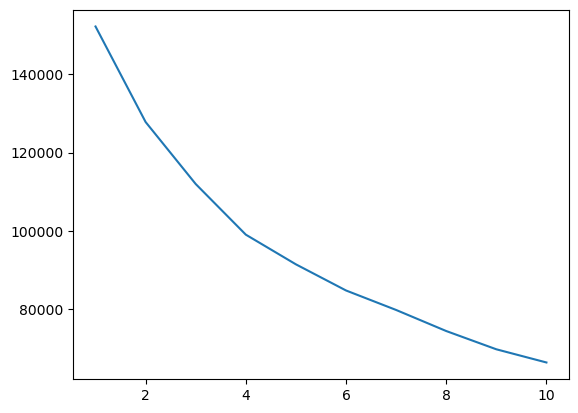

In [9]:
import matplotlib.pyplot as plt
#показываю на графике
plt.plot(range(1,11),score)

In [10]:
#Иерархическая кластериация
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(4)
label = model.fit_predict(df_scaled)

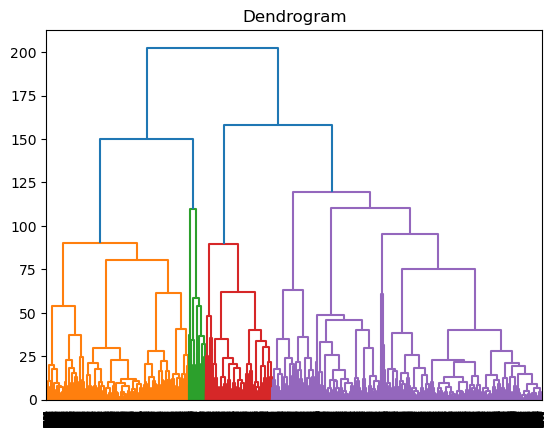

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage  

Z = linkage(df_scaled, method='ward')
dendro = dendrogram(Z)
plt.title('Dendrogram')
plt.show()       

In [12]:
df_plot = df.copy()  # исходные данные без масштабирования для интерпретации
df_plot['cluster'] = label

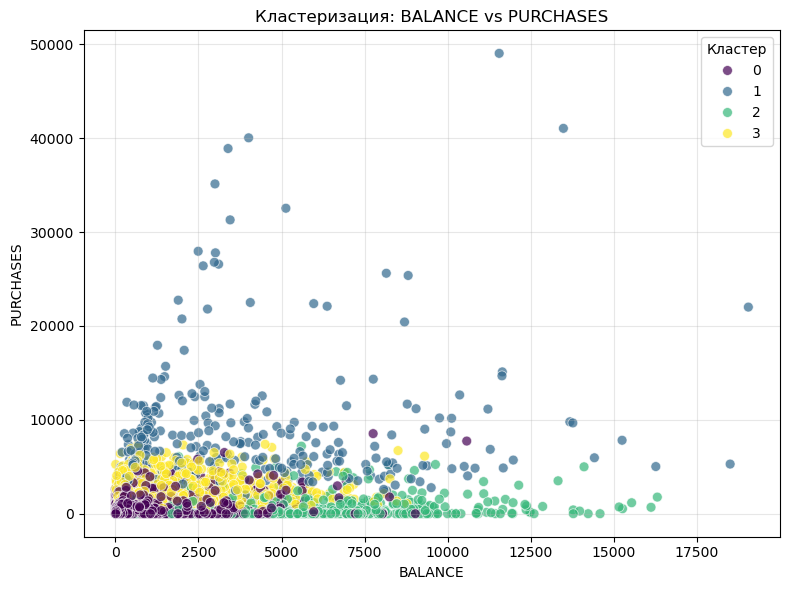

In [13]:
# === График 1: BALANCE vs PURCHASES ===
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='BALANCE',
    y='PURCHASES',
    hue='cluster',
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title('Кластеризация: BALANCE vs PURCHASES')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.legend(title='Кластер')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Выделено 4 кластера:
Кластер 0 - низкий баланс и низкие покупки
Кластер 1 - высокий баланс и очень выское покупки
Кластер 2 - высокий баланс, мало покупок
Кластер 3 - низкий баланс и средние покупки

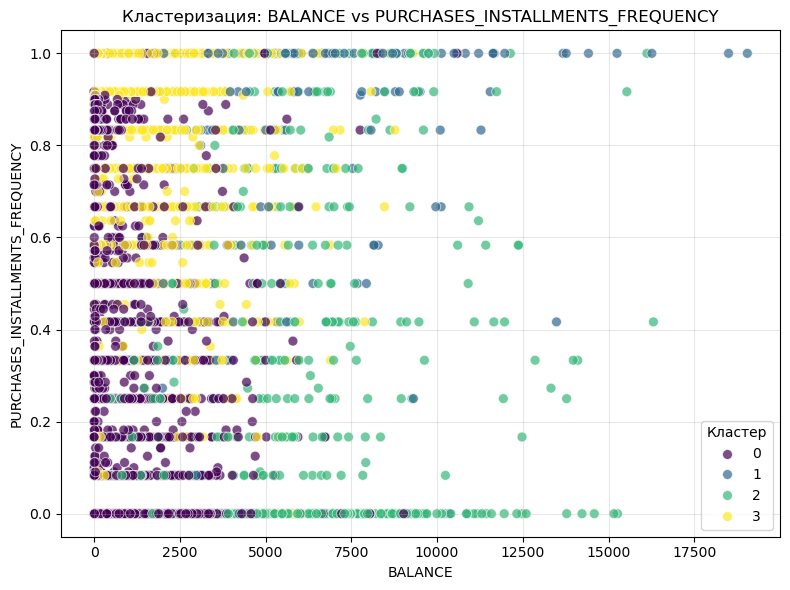


Профили кластеров (средние значения ключевых признаков):
         BALANCE  PURCHASES  PURCHASES_INSTALLMENTS_FREQUENCY  CREDIT_LIMIT  \
cluster                                                                       
0         968.72     416.37                              0.17       3338.38   
1        4036.75    8549.54                              0.72      10198.17   
2        4451.25     369.98                              0.13       7192.46   
3        1066.93    1527.41                              0.79       4766.36   

         PAYMENTS  
cluster            
0         1033.98  
1         7837.68  
2         3070.40  
3         1725.55  


In [14]:
# === График 2: BALANCE vs PPURCHASES_INSTALLMENTS_FREQUENCY ===
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='BALANCE',
    y='PURCHASES_INSTALLMENTS_FREQUENCY',
    hue='cluster',
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title('Кластеризация: BALANCE vs PURCHASES_INSTALLMENTS_FREQUENCY')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES_INSTALLMENTS_FREQUENCY')
plt.legend(title='Кластер')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# === Анализ профилей кластеров ===
print("\nПрофили кластеров (средние значения ключевых признаков):")
profile = df_plot.groupby('cluster')[['BALANCE', 'PURCHASES', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS']].mean()
print(profile.round(2))

Кластер 0 - Редко используют рассрочку (0.17). Это клиенты с низким балансом и низкими покупками 
Кластер 1 - Часто используют рассрочку (0.72). Это клиенты с разным балансом и очень высокими покупками  
Кластер 2 - Редко используют рассрочку (0.13). Это клиенты с высоким балансом, но с малыми покупками
Кластер 3 - Очень часто используют рассрочку (0.79). Это клиенты с низким балансом и средними покупками   

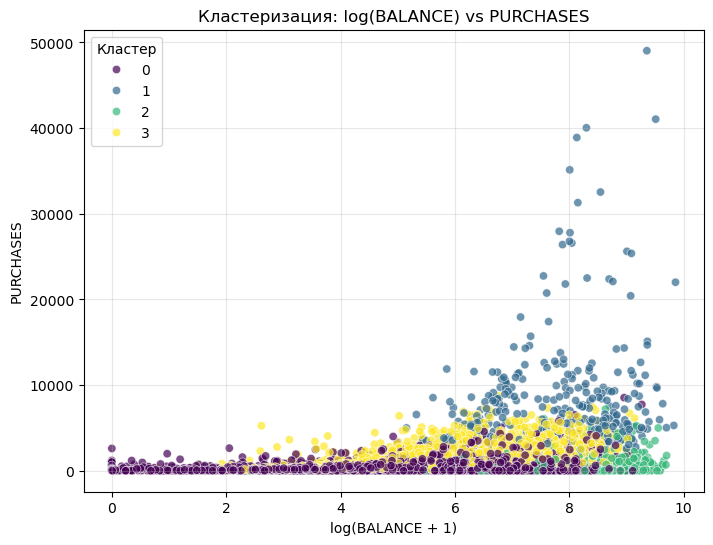

In [15]:
# Чтобы лучше понять использую логарифмическую шкалу
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x=df_plot['BALANCE'].apply(lambda x: np.log1p(x)),  # log-трансформация
    y='PURCHASES',
    hue='cluster',
    palette='viridis',
    alpha=0.7
)
plt.xlabel('log(BALANCE + 1)')
plt.ylabel('PURCHASES')
plt.title('Кластеризация: log(BALANCE) vs PURCHASES')
plt.legend(title='Кластер')
plt.grid(True, alpha=0.3)
plt.show()